In [21]:
import numpy as np
import pylab as pl
import ot
import time

### Data info

In [22]:
data = np.load("../data/manhattan.npz")

bakery_pos = data["bakery_pos"]         # Coordinates of the bakeries
bakery_prod = data["bakery_prod"]       # Production of croissants at each bakery
cafe_pos = data["cafe_pos"]             # Coordinates of the cafés
cafe_prod = data["cafe_prod"]           # Sale of croissants at each café
Imap = data["Imap"]

print("Bakery production: {}".format(bakery_prod))
print("Cafe sale: {}".format(cafe_prod))
print("Total croissants: {}".format(cafe_prod.sum()))

Bakery production: [31. 48. 82. 30. 40. 48. 89. 73.]
Cafe sale: [82. 88. 92. 88. 91.]
Total croissants: 441.0


### Plotting bakeries in the city

Text(0.5, 1.0, 'Manhattan Bakeries and Cafés')

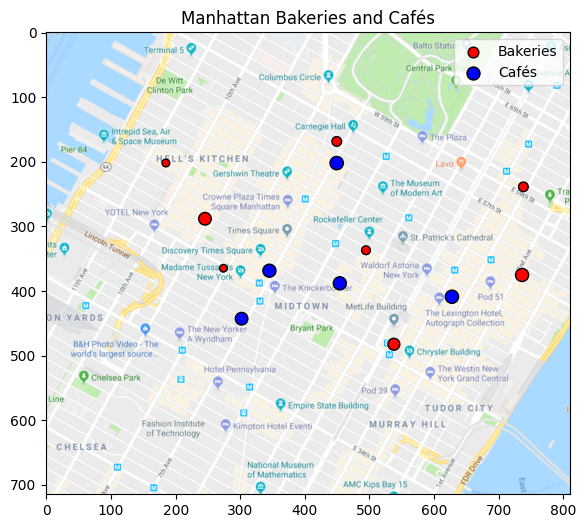

In [23]:
pl.figure(1, (7, 6))
pl.clf()
pl.imshow(Imap, interpolation="bilinear")  # plot the map
pl.scatter(
    bakery_pos[:, 0], bakery_pos[:, 1], s=bakery_prod, c="r", ec="k", label="Bakeries"
)
pl.scatter(cafe_pos[:, 0], cafe_pos[:, 1], s=cafe_prod, c="b", ec="k", label="Cafés")
pl.legend()
pl.title("Manhattan Bakeries and Cafés")

### Cost matrix

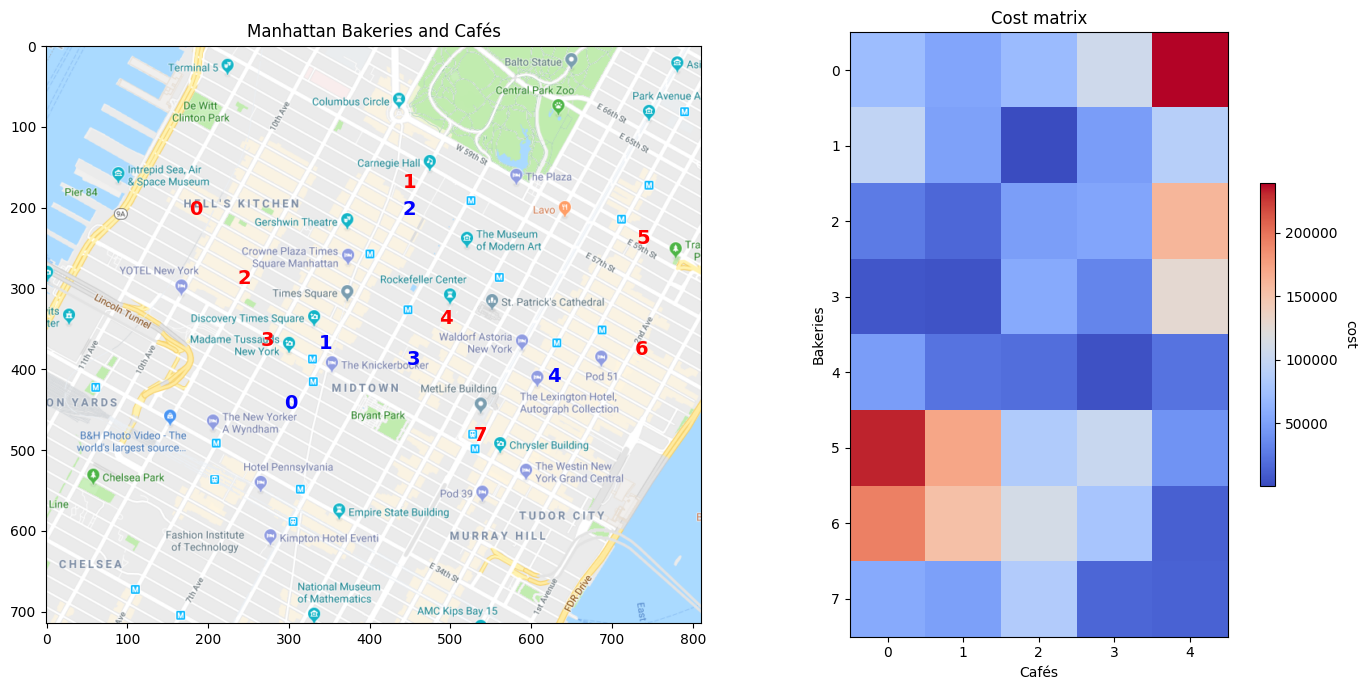

In [24]:
C = ot.dist(bakery_pos, cafe_pos)

labels = [str(i) for i in range(len(bakery_prod))]
f = pl.figure(2, (14, 7))
pl.clf()
pl.subplot(121)
pl.imshow(Imap, interpolation="bilinear")  # plot the map
for i in range(len(cafe_pos)):
    pl.text(
        cafe_pos[i, 0],
        cafe_pos[i, 1],
        labels[i],
        color="b",
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
    )
for i in range(len(bakery_pos)):
    pl.text(
        bakery_pos[i, 0],
        bakery_pos[i, 1],
        labels[i],
        color="r",
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
    )
pl.title("Manhattan Bakeries and Cafés")

ax = pl.subplot(122)
im = pl.imshow(C, cmap="coolwarm")
pl.title("Cost matrix")
cbar = pl.colorbar(im, ax=ax, shrink=0.5, use_gridspec=True)
cbar.ax.set_ylabel("cost", rotation=-90, va="bottom")

pl.xlabel("Cafés")
pl.ylabel("Bakeries")
pl.tight_layout()

### Solving the OT problem with `ot.emd`

In [25]:
start = time.time()
ot_emd = ot.emd(bakery_prod, cafe_prod, C)
time_end = time.time() - start

#### Transportation plan visualization

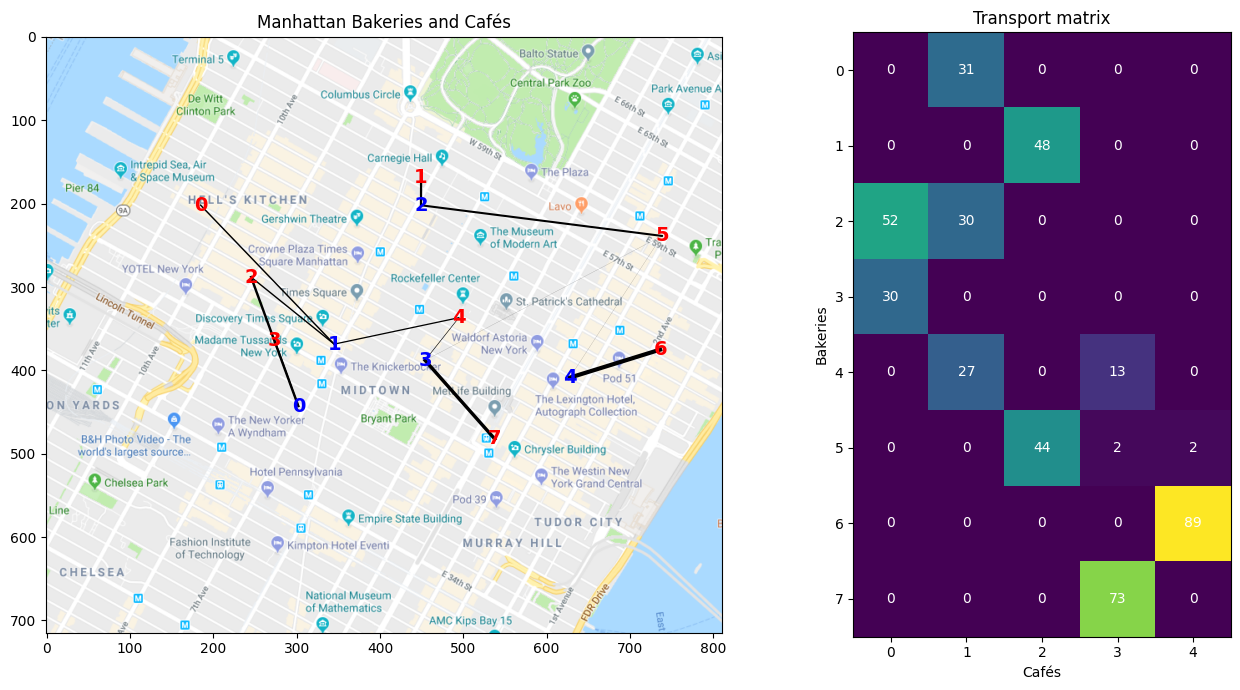

In [26]:
# Plot the matrix and the map
f = pl.figure(3, (14, 7))
pl.clf()
pl.subplot(121)
pl.imshow(Imap, interpolation="bilinear")  # plot the map
for i in range(len(bakery_pos)):
    for j in range(len(cafe_pos)):
        pl.plot(
            [bakery_pos[i, 0], cafe_pos[j, 0]],
            [bakery_pos[i, 1], cafe_pos[j, 1]],
            "-k",
            lw=3.0 * ot_emd[i, j] / ot_emd.max(),
        )
for i in range(len(cafe_pos)):
    pl.text(
        cafe_pos[i, 0],
        cafe_pos[i, 1],
        labels[i],
        color="b",
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
    )
for i in range(len(bakery_pos)):
    pl.text(
        bakery_pos[i, 0],
        bakery_pos[i, 1],
        labels[i],
        color="r",
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
    )
pl.title("Manhattan Bakeries and Cafés")

ax = pl.subplot(122)
im = pl.imshow(ot_emd)
for i in range(len(bakery_prod)):
    for j in range(len(cafe_prod)):
        text = ax.text(
            j, i, "{0:g}".format(ot_emd[i, j]), ha="center", va="center", color="w"
        )
pl.title("Transport matrix")

pl.xlabel("Cafés")
pl.ylabel("Bakeries")
pl.tight_layout()

### OT loss and dual variables

The resulting Wasserstein loss is of the form:

$$W = \Sigma_{i,j}\gamma_{i,j}C_{i,j}$$

where $\gamma$ is the optimal transport matrix.

In [27]:
W = np.sum(ot_emd * C)
print("Wasserstein loss (EMD) = {0:.2f}".format(W))

Wasserstein loss (EMD) = 10838179.41


### Regularized OT with Sinkhorn

![image](../images/SK.png)

### Algorithm

In [28]:
# Compute Sinkhorn transport matrix from algorithm
reg = 0.1
K = np.exp(-C / C.max() / reg)
nit = 100
u = np.ones((len(bakery_prod),))
for i in range(1, nit):
    v = cafe_prod / np.dot(K.T, u)
    u = bakery_prod / (np.dot(K, v))
T_algo = np.dot(np.diag(u), np.dot(K, np.diag(v)))

# Compute Sinkhorn transport matrix with POT
T_ot = ot.sinkhorn(bakery_prod, cafe_prod, reg=reg, M = C / C.max())

# Difference between two implementations
print("Difference between algo and ot api = {0:.2g}".format(np.sum(np.power(T_algo - T_ot, 2))))

Difference between algo and ot api = 2.1e-20


### Plot the matrix and the map

Min. of Sinkhorn's transport matrix = 0.0008


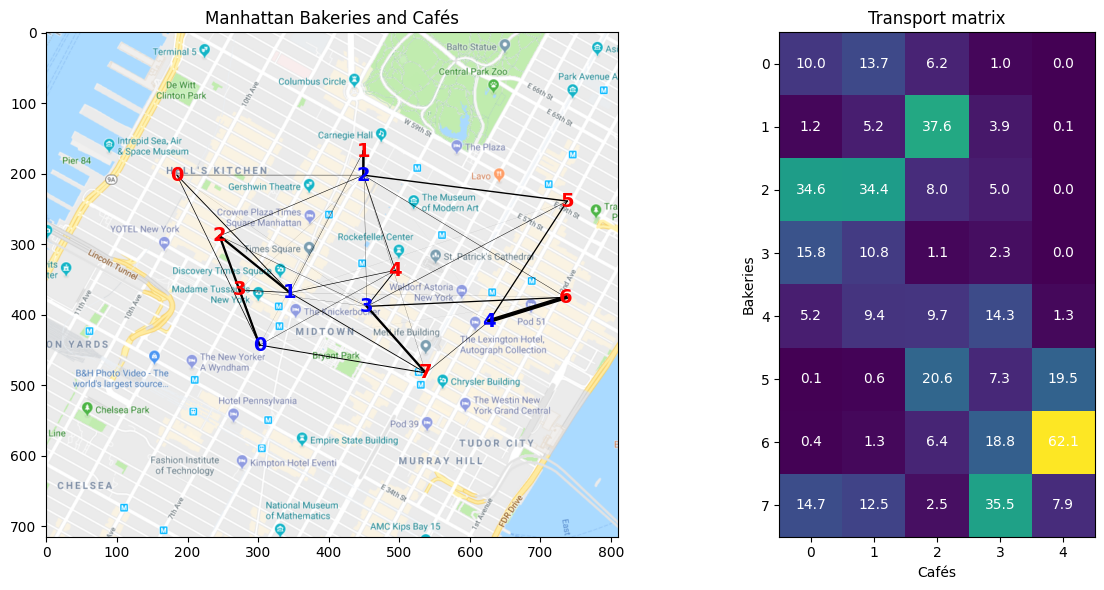

In [29]:
print("Min. of Sinkhorn's transport matrix = {0:.2g}".format(np.min(T_ot)))

f = pl.figure(4, (13, 6))
pl.clf()
pl.subplot(121)
pl.imshow(Imap, interpolation="bilinear")  # plot the map
for i in range(len(bakery_pos)):
    for j in range(len(cafe_pos)):
        pl.plot(
            [bakery_pos[i, 0], cafe_pos[j, 0]],
            [bakery_pos[i, 1], cafe_pos[j, 1]],
            "-k",
            lw=3.0 * T_ot[i, j] / T_ot.max(),
        )
for i in range(len(cafe_pos)):
    pl.text(
        cafe_pos[i, 0],
        cafe_pos[i, 1],
        labels[i],
        color="b",
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
    )
for i in range(len(bakery_pos)):
    pl.text(
        bakery_pos[i, 0],
        bakery_pos[i, 1],
        labels[i],
        color="r",
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
    )
pl.title("Manhattan Bakeries and Cafés")

ax = pl.subplot(122)
im = pl.imshow(T_ot)
for i in range(len(bakery_prod)):
    for j in range(len(cafe_prod)):
        text = ax.text(
            j, i, np.round(T_ot[i, j], 1), ha="center", va="center", color="w"
        )
pl.title("Transport matrix")

pl.xlabel("Cafés")
pl.ylabel("Bakeries")
pl.tight_layout()

### Varying the regularization parameter in Sinkhorn

/home/ansible/miniconda3/lib/python3.13/site-packages/ot/bregman/_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


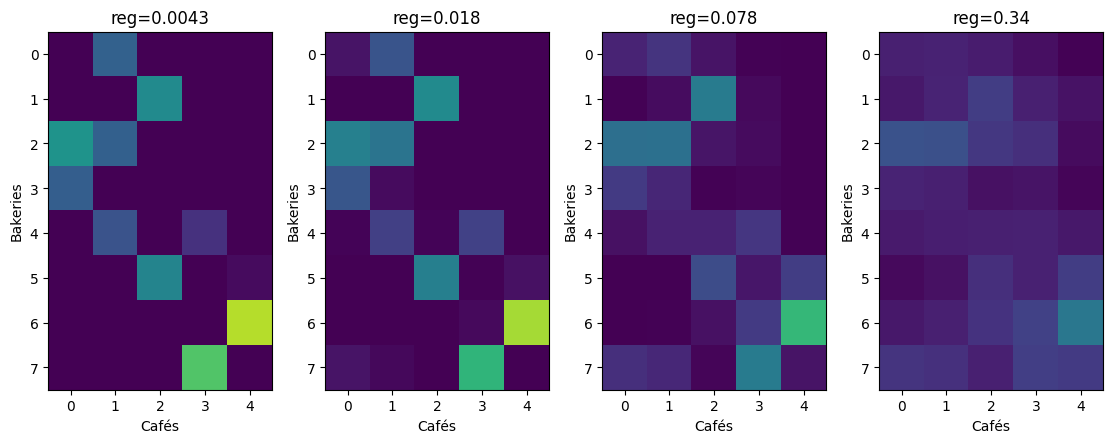

In [30]:
reg_parameter = np.logspace(-3, 0, 20)
W_sinkhorn_reg = np.zeros((len(reg_parameter),))
time_sinkhorn_reg = np.zeros((len(reg_parameter),))

f = pl.figure(5, (14, 5))
pl.clf()
max_ot = 100  # plot matrices with the same colorbar
for k in range(len(reg_parameter)):
    start = time.time()
    ot_sinkhorn = ot.sinkhorn(
        bakery_prod, cafe_prod, reg=reg_parameter[k], M=C / C.max()
    )
    time_sinkhorn_reg[k] = time.time() - start

    if k % 4 == 0 and k > 0:  # we only plot a few
        ax = pl.subplot(1, 5, k // 4)
        im = pl.imshow(ot_sinkhorn, vmin=0, vmax=max_ot)
        pl.title("reg={0:.2g}".format(reg_parameter[k]))
        pl.xlabel("Cafés")
        pl.ylabel("Bakeries")

    # Compute the Wasserstein loss for Sinkhorn, and compare with EMD
    W_sinkhorn_reg[k] = np.sum(ot_sinkhorn * C)
pl.tight_layout()

### Wasserstein loss and computational time

Text(0, 0.5, 'Wasserstein loss')

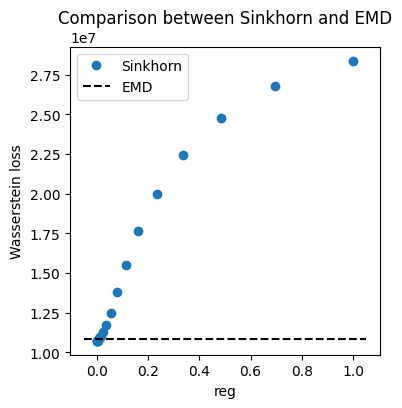

In [31]:
# Plot the matrix and the map
f = pl.figure(6, (4, 4))
pl.clf()
pl.title("Comparison between Sinkhorn and EMD")

pl.plot(reg_parameter, W_sinkhorn_reg, "o", label="Sinkhorn")
XLim = pl.xlim()
pl.plot(XLim, [W, W], "--k", label="EMD")
pl.legend()
pl.xlabel("reg")
pl.ylabel("Wasserstein loss")